# <center>Homework 100</center>

## Task 0

In [1]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

2026-01-05 15:24:19.133910: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-05 15:24:19.262424: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-05 15:24:26.589454: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
X, y = fetch_california_housing(return_X_y=True)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, random_state=42, test_size=0.2, shuffle=True) 
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, random_state=42, test_size=0.1, shuffle=True) 

In [6]:
normalization_layer = tf.keras.layers.Normalization()
hidden_layer1 = tf.keras.layers.Dense(30, activation="relu")
hidden_layer2 = tf.keras.layers.Dense(30, activation="relu")
concat_layer = tf.keras.layers.Concatenate()
output_layer = tf.keras.layers.Dense(1)

normalization_layer.adapt(X_train)

input_ = tf.keras.layers.Input(shape=X_train.shape[1:])
normalized = normalization_layer(input_)
hidden1 = hidden_layer1(normalized)
hidden2 = hidden_layer2(hidden1)
concat = concat_layer([normalized, hidden2])
output = output_layer(concat)

model = tf.keras.Model(inputs=[input_], outputs=[output])
model.compile(loss='mse', optimizer='sgd', metrics=['RootMeanSquaredError'])
model.summary()
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val))


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 8)         │         17 │ input_layer_1[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30)        │        270 │ normalization_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 30)        │        930 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 38)        │          0 │ normalization_1[… │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         39 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,256 (4.91 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 17 (72.00 B)

Epoch 1/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - RootMeanSquaredError: 0.8761 - loss: 0.7676 - val_RootMeanSquaredError: 0.7378 - val_loss: 0.5444
Epoch 2/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 3.0137 - loss: 9.0823 - val_RootMeanSquaredError: 0.8044 - val_loss: 0.6471
Epoch 3/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.7681 - loss: 0.5899 - val_RootMeanSquaredError: 0.6932 - val_loss: 0.4806
Epoch 4/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6626 - loss: 0.4391 - val_RootMeanSquaredError: 0.6635 - val_loss: 0.4402
Epoch 5/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 0.7211 - loss: 0.5200 - val_RootMeanSquaredError: 0.7431 - val_loss: 0.5522
Epoch 6/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.7233 - loss: 0.5232 - val_RootMeanSquaredError: 0.6425 - val_loss: 0.4128
Epoch 7/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 0.6094 - los

In [9]:
model.save('keras_model.keras')

In [4]:
load_model = tf.keras.models.load_model('keras_model.keras')

load_model.predict(X_test[:3])

2026-01-05 15:25:03.685931: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


array([[0.32253063],
       [1.4007928 ],
       [4.399036  ]], dtype=float32)

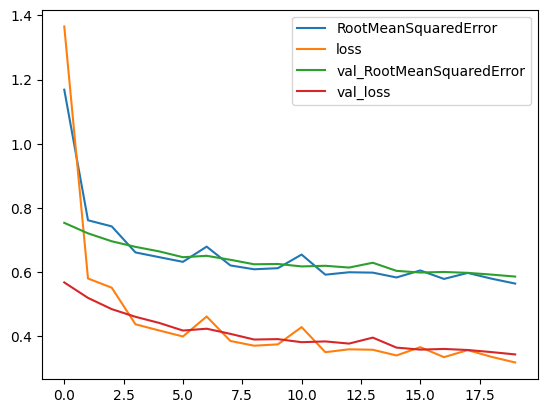

In [7]:
pd_history = pd.DataFrame(history.history)
pd_history.plot()
plt.legend()

In [9]:
input_wide = tf.keras.layers.Input(shape=[5]) # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6]) # features 2 to 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)

model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

X_train_wide, X_train_deep = X_train[:, :5], X_train[:, 2:]
X_valid_wide, X_valid_deep = X_val[:, :5], X_val[:, 2:]
X_test_wide, X_test_deep = X_test[:, :5], X_test[:, 2:]
X_new_wide, X_new_deep = X_test_wide[:3], X_test_deep[:3]

norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)

model.summary()

history = model.fit((X_train_wide, X_train_deep), y_train, epochs=20,
                                                validation_data=((X_valid_wide, X_valid_deep), y_val))

print('------------- Evaluate -------------')
mse_test = model.evaluate((X_test_wide, X_test_deep), y_test)

print('------------- Predict -------------')
y_pred = model.predict((X_new_wide, X_new_deep))

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_5     │ (None, 6)         │         13 │ input_layer_5[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 30)        │        210 │ normalization_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_4     │ (None, 5)         │         11 │ input_layer_4[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 30)        │        930 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 35)        │          0 │ normalization_4[… │
│ (Concatenate)       │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │         36 │ concatenate_3[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,200 (4.70 KB)

 Trainable params: 1,176 (4.59 KB)

 Non-trainable params: 24 (104.00 B)

Epoch 1/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - RootMeanSquaredError: 1.3123 - loss: 1.7222 - val_RootMeanSquaredError: 0.9445 - val_loss: 0.8922
Epoch 2/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.7934 - loss: 0.6295 - val_RootMeanSquaredError: 0.7991 - val_loss: 0.6386
Epoch 3/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 0.7000 - loss: 0.4900 - val_RootMeanSquaredError: 0.7147 - val_loss: 0.5108
Epoch 4/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.6516 - loss: 0.4245 - val_RootMeanSquaredError: 0.6704 - val_loss: 0.4494
Epoch 5/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.6279 - loss: 0.3943 - val_RootMeanSquaredError: 0.6443 - val_loss: 0.4151
Epoch 6/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 0.6070 - loss: 0.3684 - val_RootMeanSquaredError: 0.6383 - val_loss: 0.4074
Epoch 7/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 0.5983 - los

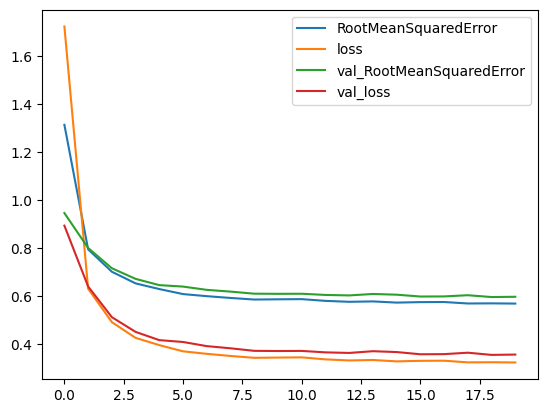

In [10]:
pd_history = pd.DataFrame(history.history)
pd_history.plot()
plt.legend()

In [15]:
input_wide = tf.keras.layers.Input(shape=[5]) # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6]) # features 2 to 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1, name='output')(concat)
aux_output = tf.keras.layers.Dense(1, name='aux_output')(hidden2)
model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output, aux_output])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss=("mse", "mse"), loss_weights=(0.9, 0.1), optimizer=optimizer, metrics=["RootMeanSquaredError"] * 2)

model.summary()
norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)

history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=20,
    validation_data=((X_valid_wide, X_valid_deep), (y_val, y_val))
)

print('------------- Evaluate -------------')
mse_test = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test), return_dict=True)
print(mse_test)

print('------------- Predict -------------')
y_pred = model.predict((X_new_wide, X_new_deep))
print(y_pred)

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_15    │ (None, 6)         │         13 │ input_layer_15[0… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_14      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 30)        │        210 │ normalization_15… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_14    │ (None, 5)         │         11 │ input_layer_14[0… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 30)        │        930 │ dense_28[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 35)        │          0 │ normalization_14… │
│ (Concatenate)       │                   │            │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         36 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aux_output (Dense)  │ (None, 1)         │         31 │ dense_29[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,231 (4.82 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 24 (104.00 B)

Epoch 1/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - aux_output_RootMeanSquaredError: 1.5331 - aux_output_loss: 2.3486 - loss: 1.3772 - output_RootMeanSquaredError: 1.1265 - output_loss: 1.2684 - val_aux_output_RootMeanSquaredError: 0.9852 - val_aux_output_loss: 0.9732 - val_loss: 0.6545 - val_output_RootMeanSquaredError: 0.7870 - val_output_loss: 0.6219
Epoch 2/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - aux_output_RootMeanSquaredError: 0.8585 - aux_output_loss: 0.7370 - loss: 0.5082 - output_RootMeanSquaredError: 0.6948 - output_loss: 0.4830 - val_aux_output_RootMeanSquaredError: 0.8459 - val_aux_output_loss: 0.7185 - val_loss: 0.5083 - val_output_RootMeanSquaredError: 0.6966 - val_output_loss: 0.4872
Epoch 3/20
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - aux_output_RootMeanSquaredError: 0.7607 - aux_output_loss: 0.5781 - loss: 0.4348 - output_RootMeanSquaredError: 0.6472 - output_loss: 0.4187 - val_aux_output_RootMeanSquaredError: 0.8109 - val_aux_output_loss: 0.6605 - val_loss: 0

## Task 3

In [16]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import tensorflow as tf

X, y = fetch_california_housing(return_X_y=True)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, random_state=42, test_size=0.2, shuffle=True) 
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, random_state=42, test_size=0.1, shuffle=True) 


seq = tf.keras.Sequential()
seq.add(tf.keras.layers.Input(X_train.shape[1:]))
seq.add(tf.keras.layers.Normalization())
seq.add(tf.keras.layers.Dense(30))
seq.add(tf.keras.layers.Dense(10))
seq.add(tf.keras.layers.Dense(1))

seq.compile(optimizer='sgd', loss='mse', metrics=['RootMeanSquaredError'])
seq.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val))

Epoch 1/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - RootMeanSquaredError: nan - loss: nan - val_RootMeanSquaredError: nan - val_loss: nan
Epoch 2/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: nan - loss: nan - val_RootMeanSquaredError: nan - val_loss: nan
Epoch 3/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: nan - loss: nan - val_RootMeanSquaredError: nan - val_loss: nan
Epoch 4/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: nan - loss: nan - val_RootMeanSquaredError: nan - val_loss: nan
Epoch 5/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: nan - loss: nan - val_RootMeanSquaredError: nan - val_loss: nan
Epoch 6/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: nan - loss: nan - val_RootMeanSquaredError: nan - val_loss: nan
Epoch 7/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: nan - loss: nan - val_RootMeanSquaredError: nan - val_loss: nan
Epoch 8/30
465/465 ━